In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import uproot
import awkward as ak
import os
from matplotlib import rcParams

%matplotlib inline

rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

# RUN1848

In [2]:
import glob

csv_folder = "/scratch/elena/9Li/results/run1848"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filtrar CSV vacíos
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_chunk = df_chunk[['t_window_start_s', 't_window_start_rel_ms', 'nHits', 'spill_id']]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")  #era hasta el 47 en el .sh 

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)


Found 48 chunk files


In [12]:
import glob
import pandas as pd

csv_folder = "/scratch/elena/9Li/results/run1848"
csv_files = sorted(glob.glob(f"{csv_folder}/Li9_clusters_chunk_*.csv"))

print(f"Found {len(csv_files)} chunk files")

df_list = []
for f in csv_files:
    try:
        df_chunk = pd.read_csv(f)
        if not df_chunk.empty:   # filter empty CSVs
            # Add new columns without dropping any existing ones
            df_chunk['t_window_start_s'] = df_chunk['t_window_start_ns'] / 1e9            # absolute time [s]
            df_chunk['t_window_start_rel_ms'] = df_chunk['t_window_start_rel_ns'] / 1e6   # relative time [ms]

            df_list.append(df_chunk)
    except pd.errors.EmptyDataError:
        print(f"Skipping empty file: {f}")

# concatenate all chunks
df = pd.concat(df_list, ignore_index=True)

print(f"Total clusters: {len(df)}")
display(df)

Found 48 chunk files
Total clusters: 893933


,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,t_window_start_s,t_window_start_rel_ms
0,1.600714e+10,8.209895e+04,446,0,"[26, 23, 23, 83, 80, 25, 21, 21, 21, 21, 20, 2...","[60, 47, 47, 28, 30, 62, 64, 64, 64, 64, 81, 8...","[14, 14, 12, 15, 13, 16, 0, 1, 15, 14, 9, 14, ...","[13, 13, 4, 5, 12, 14, 17, 6, 5, 13, 3, 13, 3,...","[16007140394.253225, 16007140392.605368, 16007...","[101.0, 75.0, 169.0, 96.0, 171.0, 101.0, 249.0...",16.007140,0.082099
1,1.600714e+10,8.211898e+04,125,0,"[34, 34, 35, 35, 42, 32, 26, 26, 26, 23, 23, 1...","[78, 78, 76, 76, 80, 75, 60, 60, 60, 47, 47, 7...","[0, 17, 0, 16, 18, 7, 6, 10, 12, 18, 9, 4, 8, ...","[17, 15, 17, 14, 16, 2, 8, 10, 4, 16, 3, 1, 9,...","[16007140414.384735, 16007140409.24541, 160071...","[106.0, 160.0, 201.0, 191.0, 121.0, 149.0, 103...",16.007140,0.082119
2,1.600714e+10,8.597224e+04,25,0,"[16, 21, 21, 98, 47, 99, 99, 19, 1, 27, 11, 46...","[73, 64, 64, 100, 13, 90, 90, 41, 70, 2, 10, 4...","[3, 5, 15, 11, 16, 5, 8, 2, 7, 0, 8, 9, 2, 9, ...","[18, 7, 5, 11, 14, 7, 9, 0, 2, 17, 9, 3, 0, 3,...","[16007144267.85772, 16007144256.741348, 160071...","[97.0, 124.0, 74.0, 183.0, 137.0, 157.0, 219.0...",16.007144,0.085972
3,1.600717e+10,1.112848e+05,176,0,"[23, 83, 80, 80, 80, 17, 20, 20, 20, 73, 73, 4...","[47, 28, 30, 30, 30, 29, 81, 81, 81, 31, 31, 1...","[18, 18, 6, 7, 18, 10, 1, 5, 7, 2, 5, 9, 16, 1...","[16, 16, 8, 2, 16, 10, 6, 7, 2, 0, 7, 3, 14, 1...","[16007169580.691437, 16007169575.396912, 16007...","[113.0, 67.0, 419.0, 275.0, 83.0, 165.0, 226.0...",16.007170,0.111285
4,1.600717e+10,1.113049e+05,17,0,"[26, 80, 17, 73, 44, 107, 99, 22, 18, 52, 76, ...","[60, 30, 29, 31, 43, 44, 90, 82, 69, 6, 86, 35...","[5, 2, 15, 4, 15, 0, 17, 17, 4, 16, 12, 4, 17,...","[7, 0, 5, 1, 5, 17, 15, 15, 1, 14, 4, 1, 15, -...","[16007169593.366247, 16007169593.98172, 160071...","[57.0, 260.0, 99.0, 182.0, 154.0, 134.0, 405.0...",16.007170,0.111305
...,...,...,...,...,...,...,...,...,...,...,...,...
893928,2.176116e+12,4.984136e+08,234,55,"[111, 111, 15, 103, 26, 26, 26, 26, 26, 26, 26...","[97, 97, 58, 98, 60, 60, 60, 60, 60, 60, 60, 6...","[5, 10, 4, 10, 2, 4, 11, 12, 13, 8, 9, 14, 16,...","[7, 10, 1, 10, 0, 1, 11, 4, 12, 9, 3, 13, 14, ...","[2176115575256.613, 2176115575257.751, 2176115...","[180.0, 154.0, 167.0, 270.0, 332.0, 260.0, 82....",2176.115575,498.413582
893929,2.176116e+12,4.984136e+08,20,55,"[99, 93, 98, 23, 20, 107, 8, 18, 30, 94, 75, 7...","[90, 101, 100, 47, 81, 44, 84, 69, 52, 11, 95,...","[12, 18, 9, 2, 5, 2, 6, 10, 3, 1, 3, 13, 1, 18...","[4, 16, 3, 0, 7, 0, 8, 10, 18, 6, 18, 12, 6, 1...","[2176115575277.3162, 2176115575273.8496, 21761...","[188.0, 163.0, 85.0, 119.0, 135.0, 91.0, 122.0...",2176.115575,498.413603
893930,2.176116e+12,4.987488e+08,224,55,"[26, 99, 10, 10, 10, 93, 93, 93, 21, 21, 21, 2...","[60, 90, 61, 61, 61, 101, 101, 101, 64, 64, 64...","[9, 1, 14, 16, 18, 2, 3, 5, 6, 8, 9, 10, 11, 1...","[3, 6, 13, 14, 16, 0, 18, 7, 8, 9, 3, 10, 11, ...","[2176115910516.4019, 2176115910522.0562, 21761...","[216.0, 178.0, 547.0, 125.0, 187.0, 119.0, 194...",2176.115911,498.748848
893931,2.176116e+12,4.987489e+08,16,55,"[111, 99, 93, 89, 27, 115, 6, 6, 94, 91, 102, ...","[97, 90, 101, 89, 2, 57, 39, 39, 11, 94, 22, 2...","[15, 9, 12, 18, 3, 3, 5, 9, 4, 6, 11, 13, 14, ...","[5, 3, 4, 16, 18, 18, 7, 3, 1, 8, 11, 12, 13, ...","[2176115910538.2803, 2176115910550.391, 217611...","[165.0, 155.0, 255.0, 112.0, 118.0, 125.0, 123...",2176.115911,498.748868


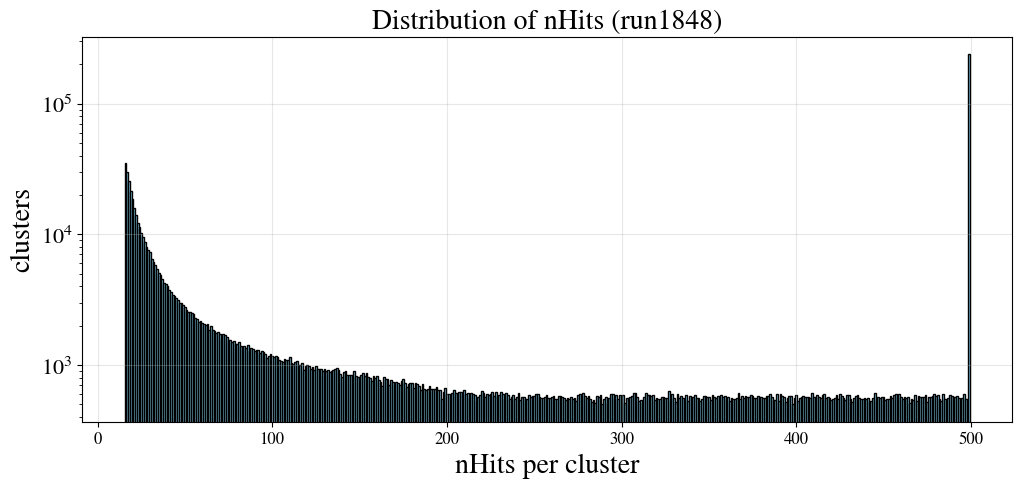

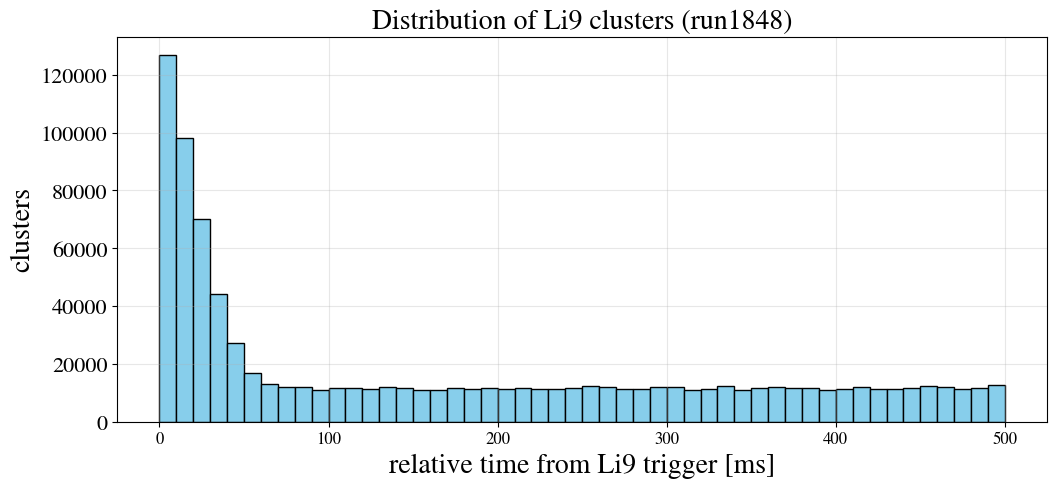

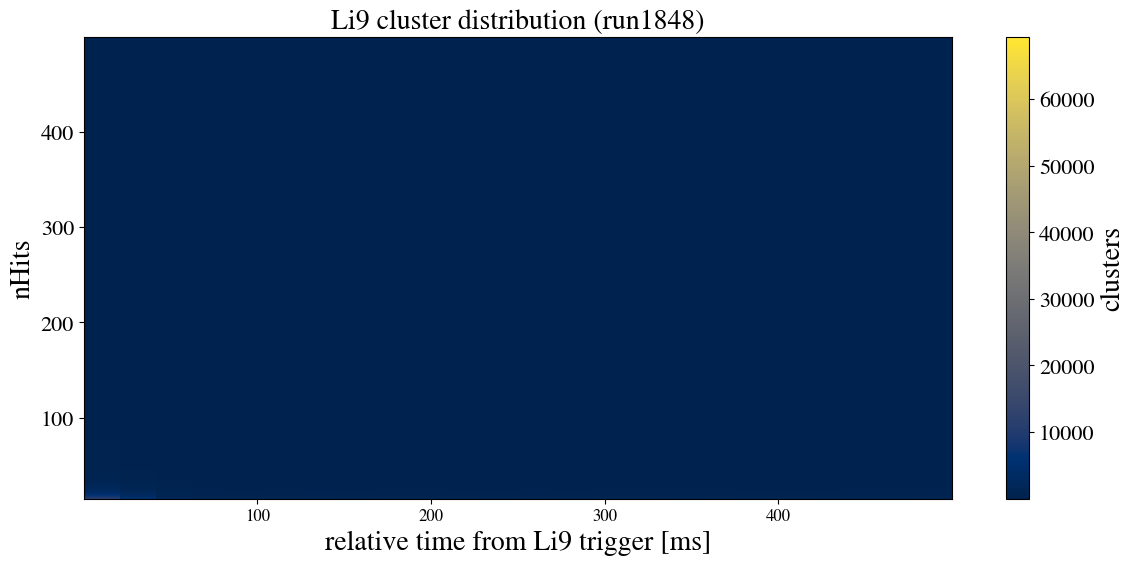

In [13]:
# -------------------------
# 2. 1D Histograms
# -------------------------

# Histogram: nHits per cluster
plt.figure(figsize=(12,5))
n_bins = np.arange(df['nHits'].min(), df['nHits'].max()+2) - 0.5            # +2 ensures the top-most value lands in a bin, the -0.5 centers bins on integers.
plt.hist(df['nHits'], bins=n_bins, color='skyblue', edgecolor='black')      #that's why we were missing the peak @ 40 before (only +1)
plt.yscale("log")
plt.xlabel("nHits per cluster")
plt.ylabel("clusters")
plt.title("Distribution of nHits (run1848)")
plt.grid(True, alpha=0.3)
plt.show()

# Histogram: relative time from Li9 window start
plt.figure(figsize=(12,5))
plt.hist(df['t_window_start_rel_ms'], bins=50, color='skyblue', edgecolor='black')
plt.xlabel("relative time from Li9 trigger [ms]")
plt.ylabel("clusters")
plt.title("Distribution of Li9 clusters (run1848)")
plt.grid(True, alpha=0.3)
plt.show()

# -------------------------
# 3. 2D Histogram / Heatmap
# -------------------------

x = df['t_window_start_rel_ms']
y = df['nHits']

# Binning
x_bins = np.linspace(x.min(), x.max(), 25)       # finer bins for time
y_bins = np.arange(y.min()-0.5, y.max()+1.5, 1)  # integer nHits bins

H, xedges, yedges = np.histogram2d(x, y, bins=[x_bins, y_bins])

plt.figure(figsize=(14,6))
plt.pcolormesh(xedges, yedges, H.T, cmap='cividis', shading='auto')
plt.colorbar(label='clusters')
plt.xlabel('relative time from Li9 trigger [ms]')
plt.ylabel('nHits')
plt.title('Li9 cluster distribution (run1848)')
plt.show()